In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob

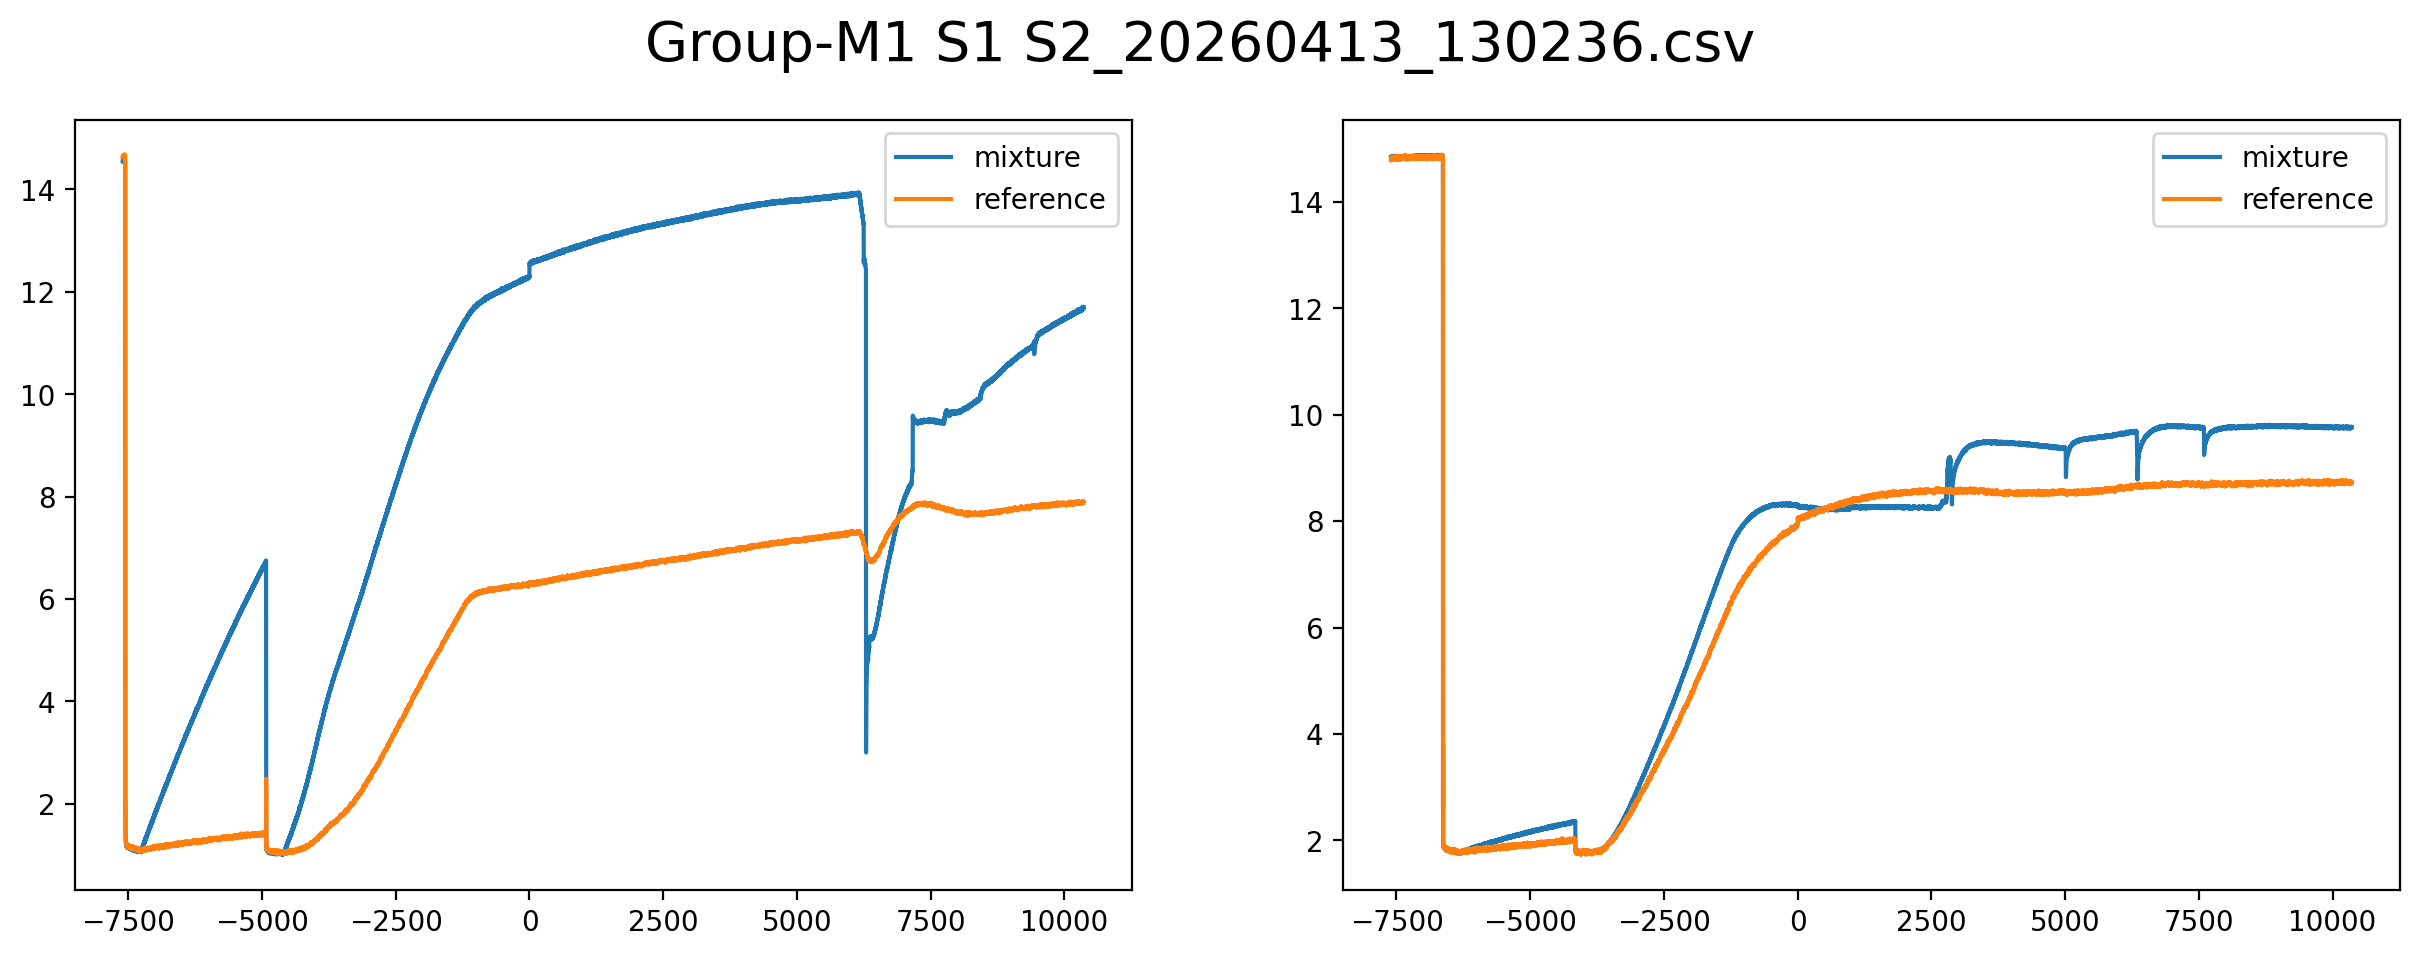

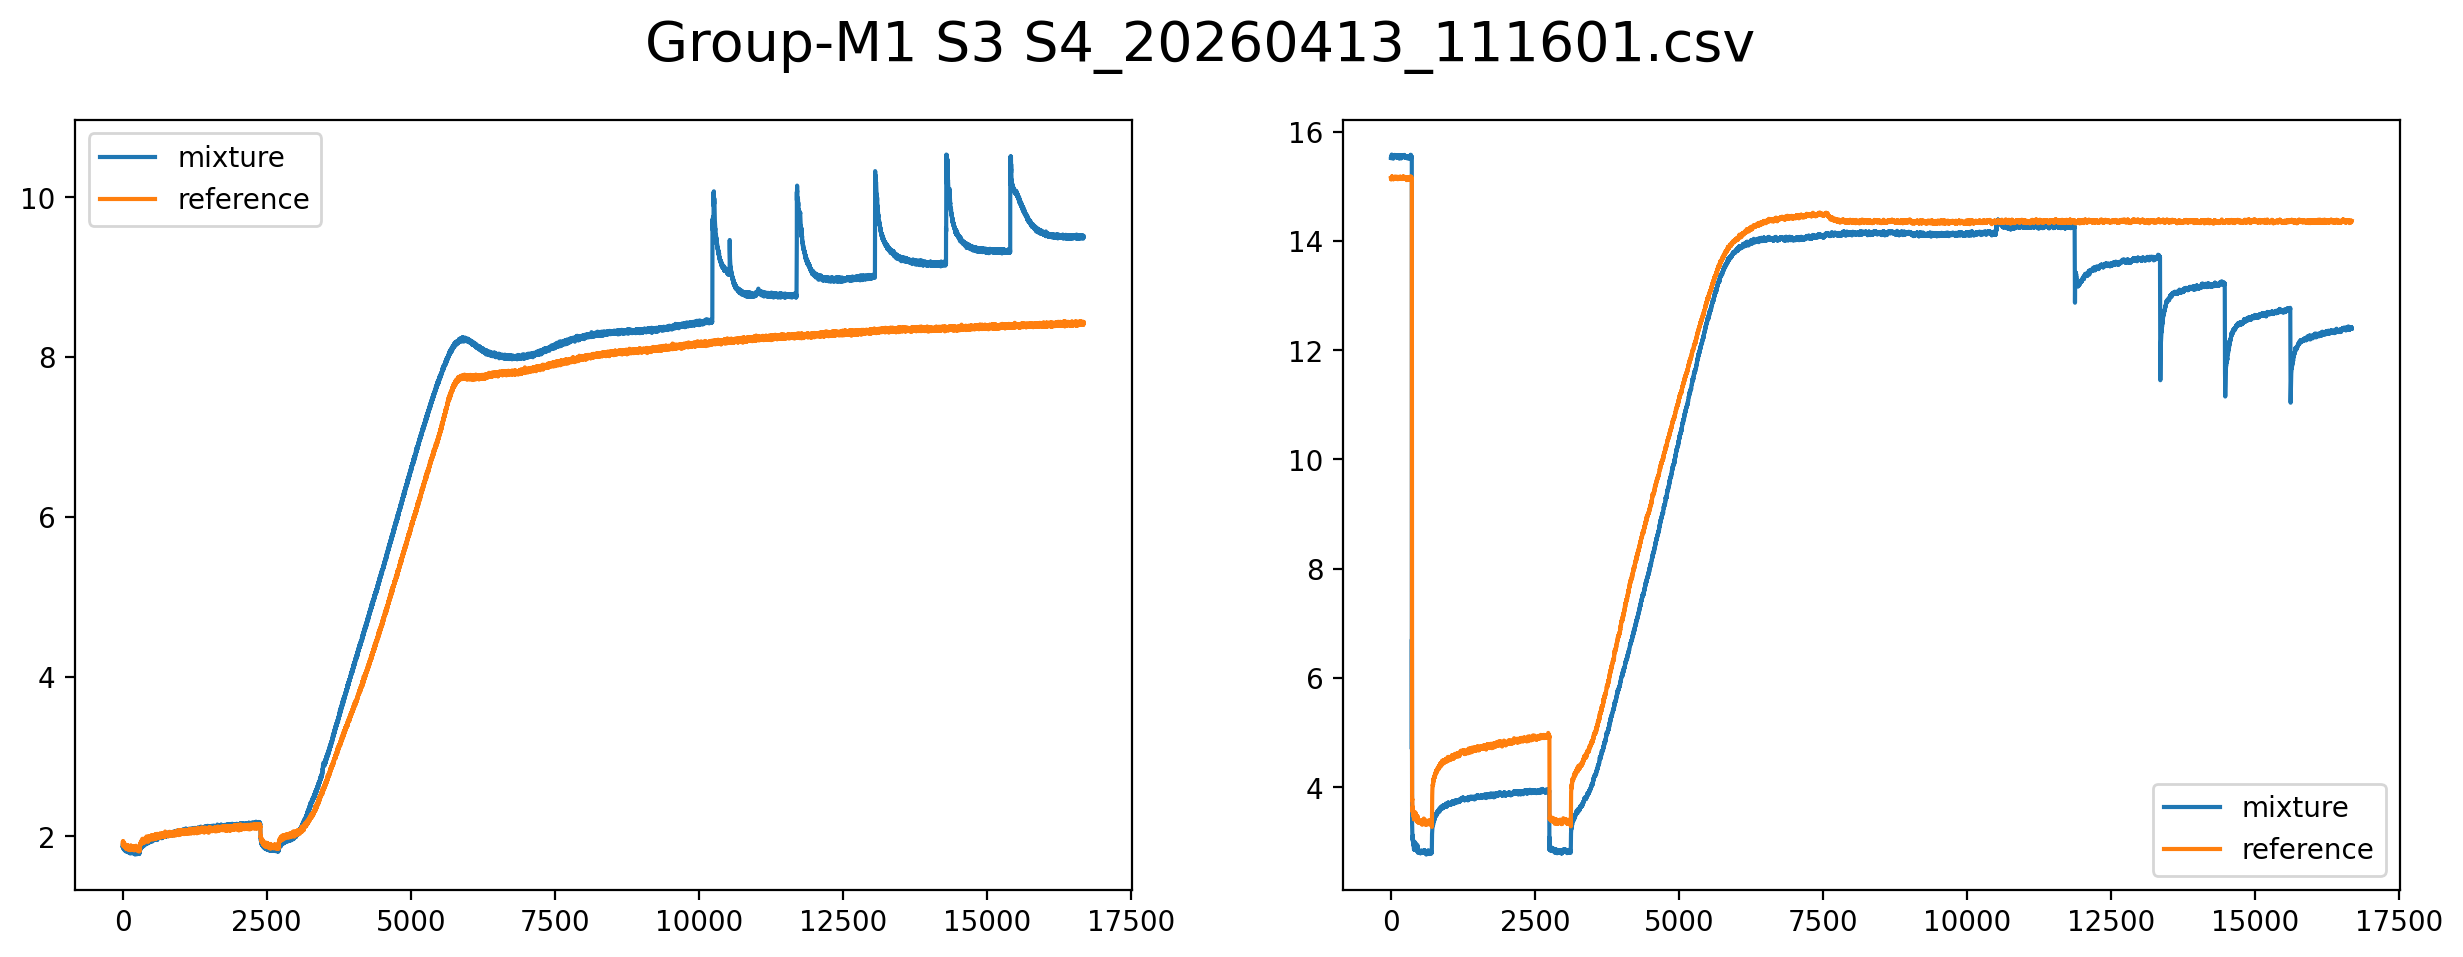

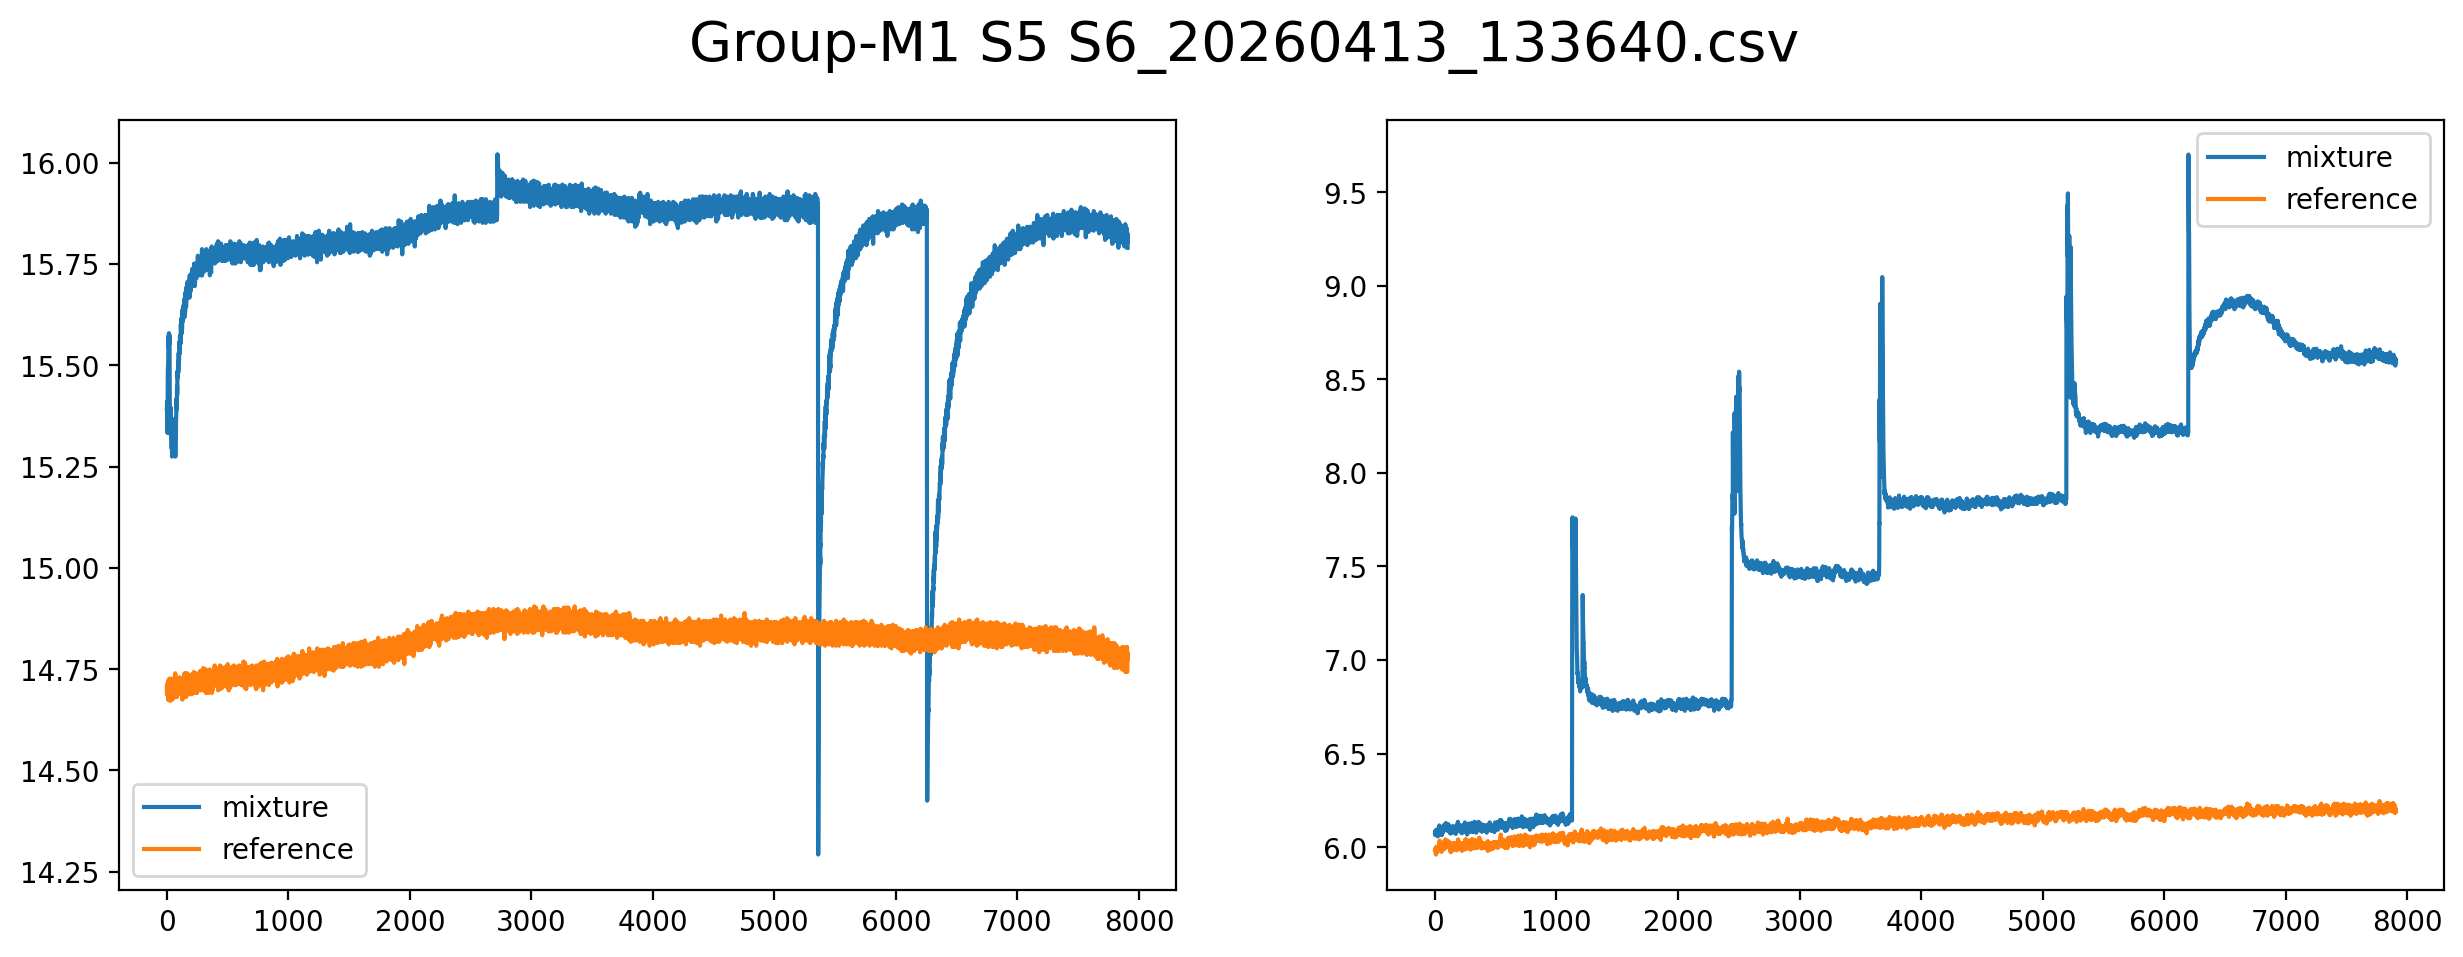

In [2]:
# t,S1 ref T,S1 air 1 T,S1 air 2 T,S1 mix T,S2 ref T,S2 air 1 T,S2 air 2 T,S2 mix T,S1 ref P,S1 mix P,S2 ref P,S2 mix P
files = glob('Group*.csv')

for file in files:
    df = pd.read_csv(file)
    fig,ax = plt.subplots(1,2,dpi=200, figsize=(15,5))
    
    ax[0].plot(df['t'], df[df.columns[-3]], label='mixture')
    ax[0].plot(df['t'], df[df.columns[-4]], label='reference')
    ax[0].legend()

    ax[1].plot(df['t'], df[df.columns[-1]], label='mixture')
    ax[1].plot(df['t'], df[df.columns[-2]], label='reference')
    ax[1].legend()
    fig.suptitle(file, fontsize=20)

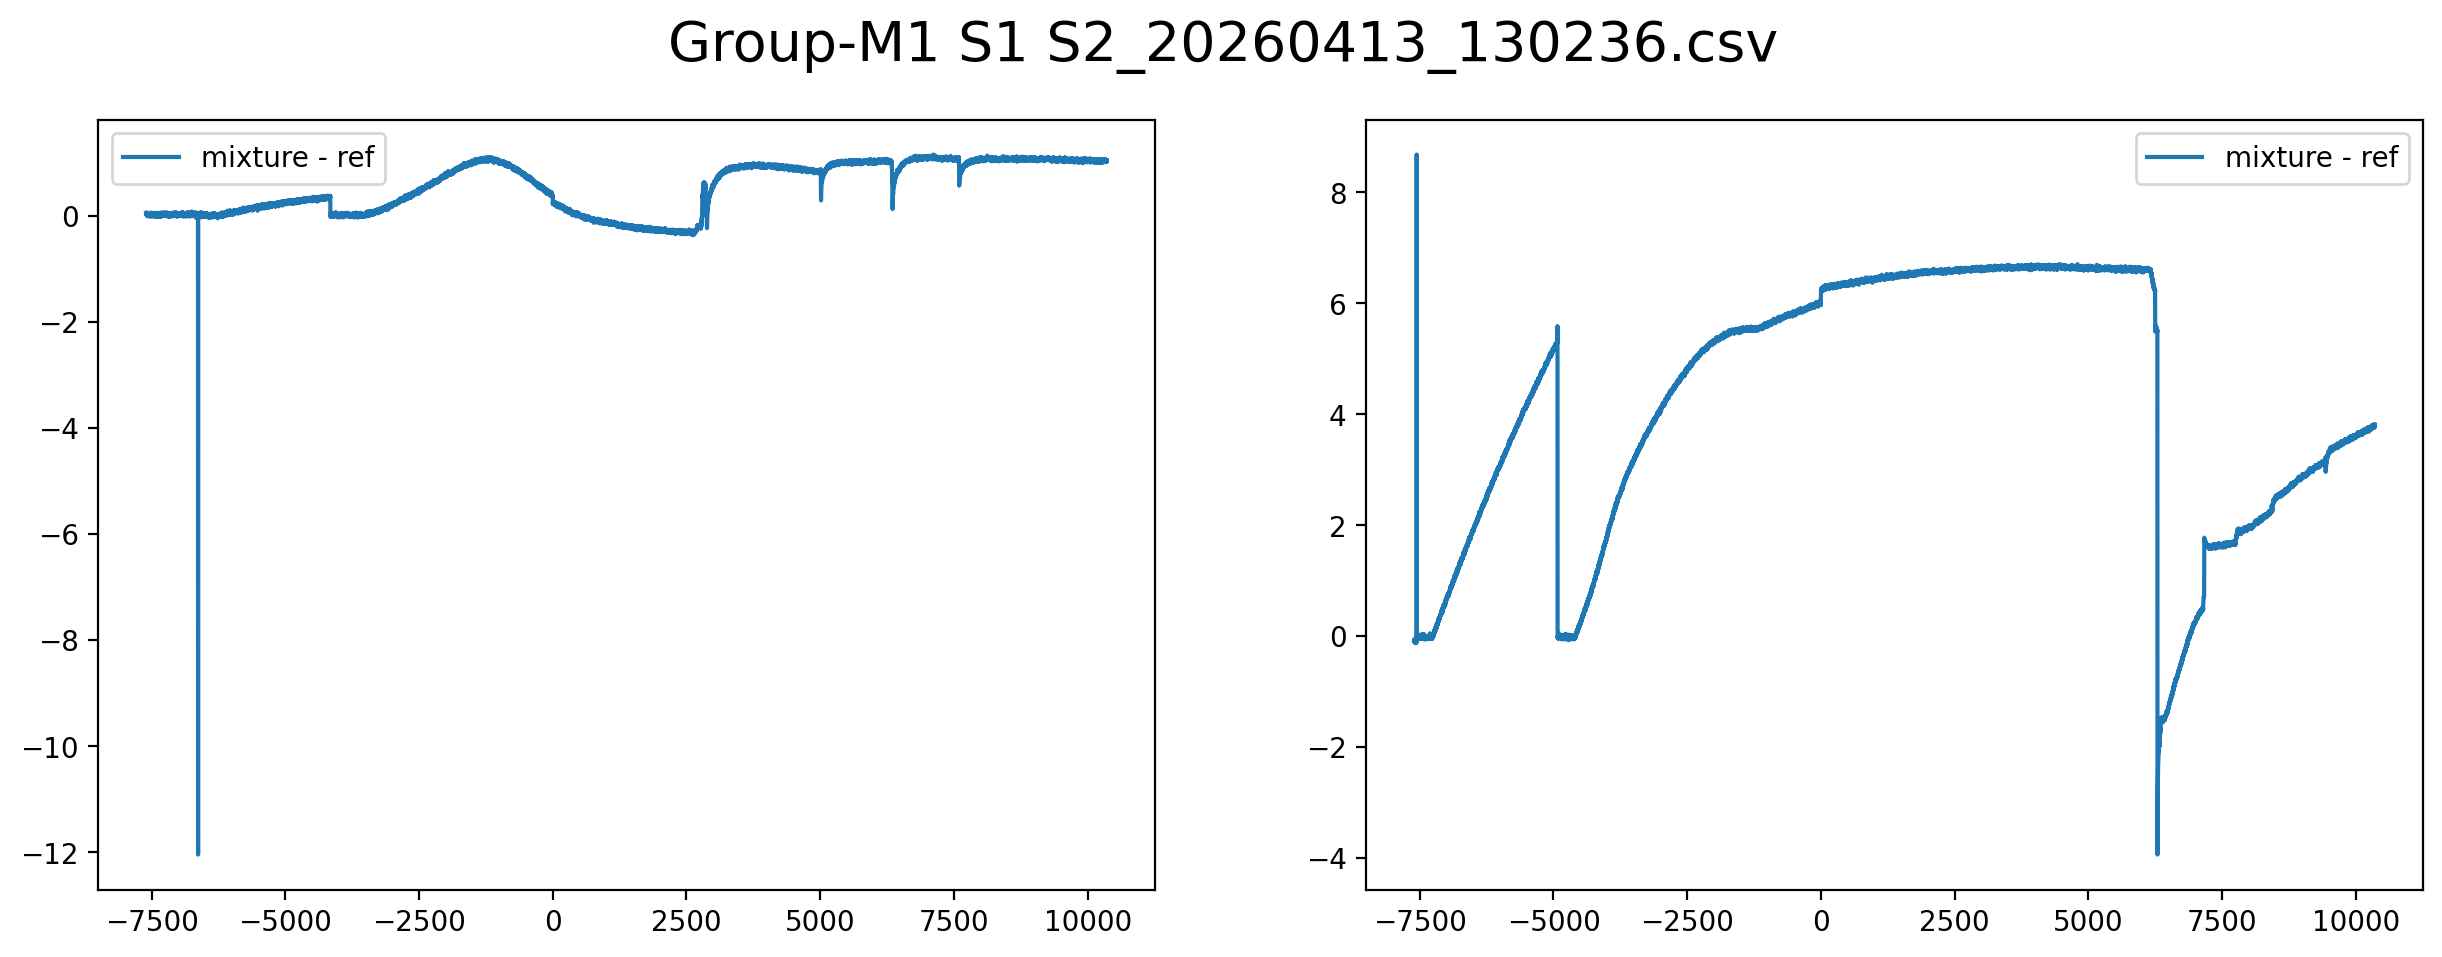

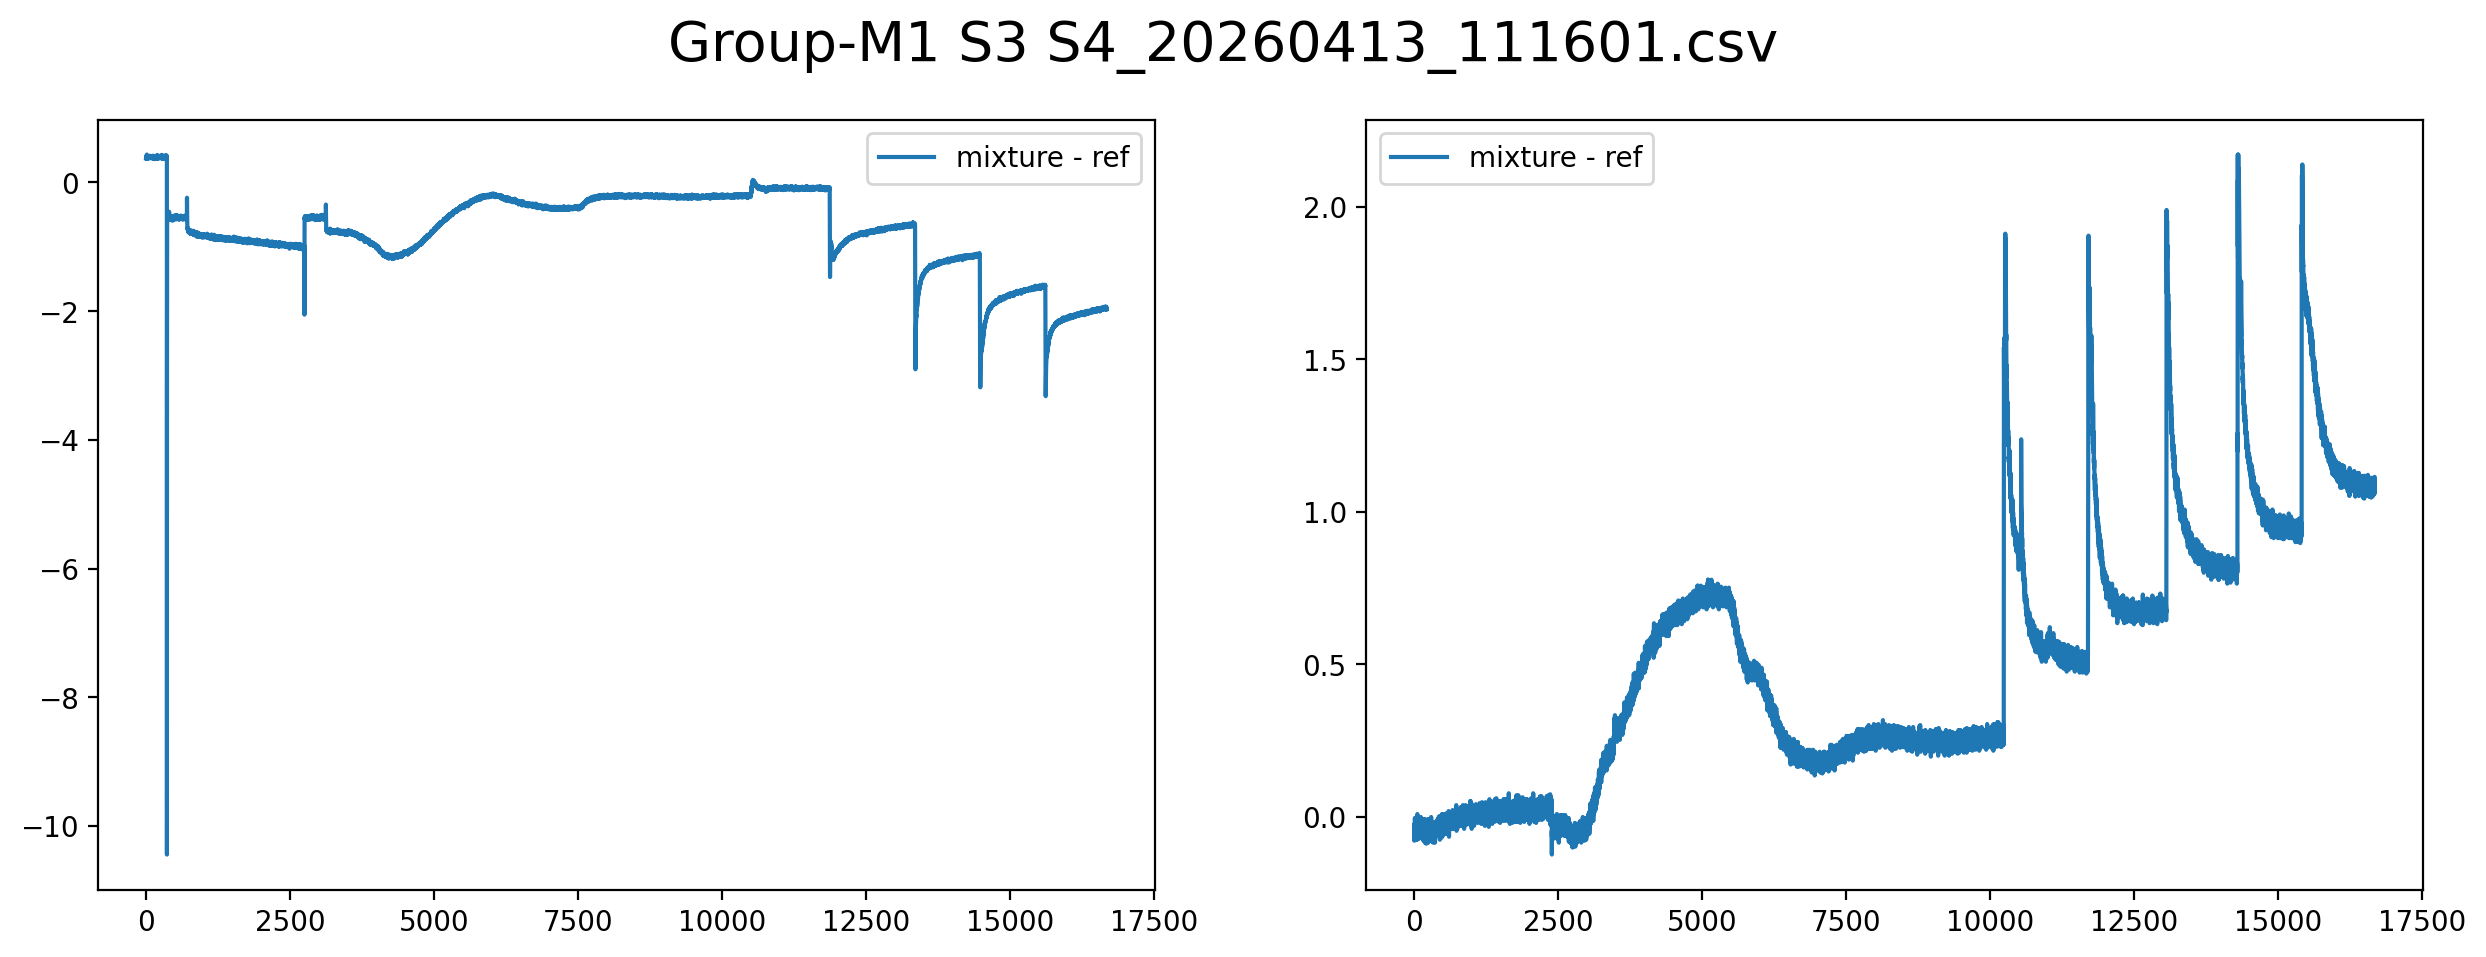

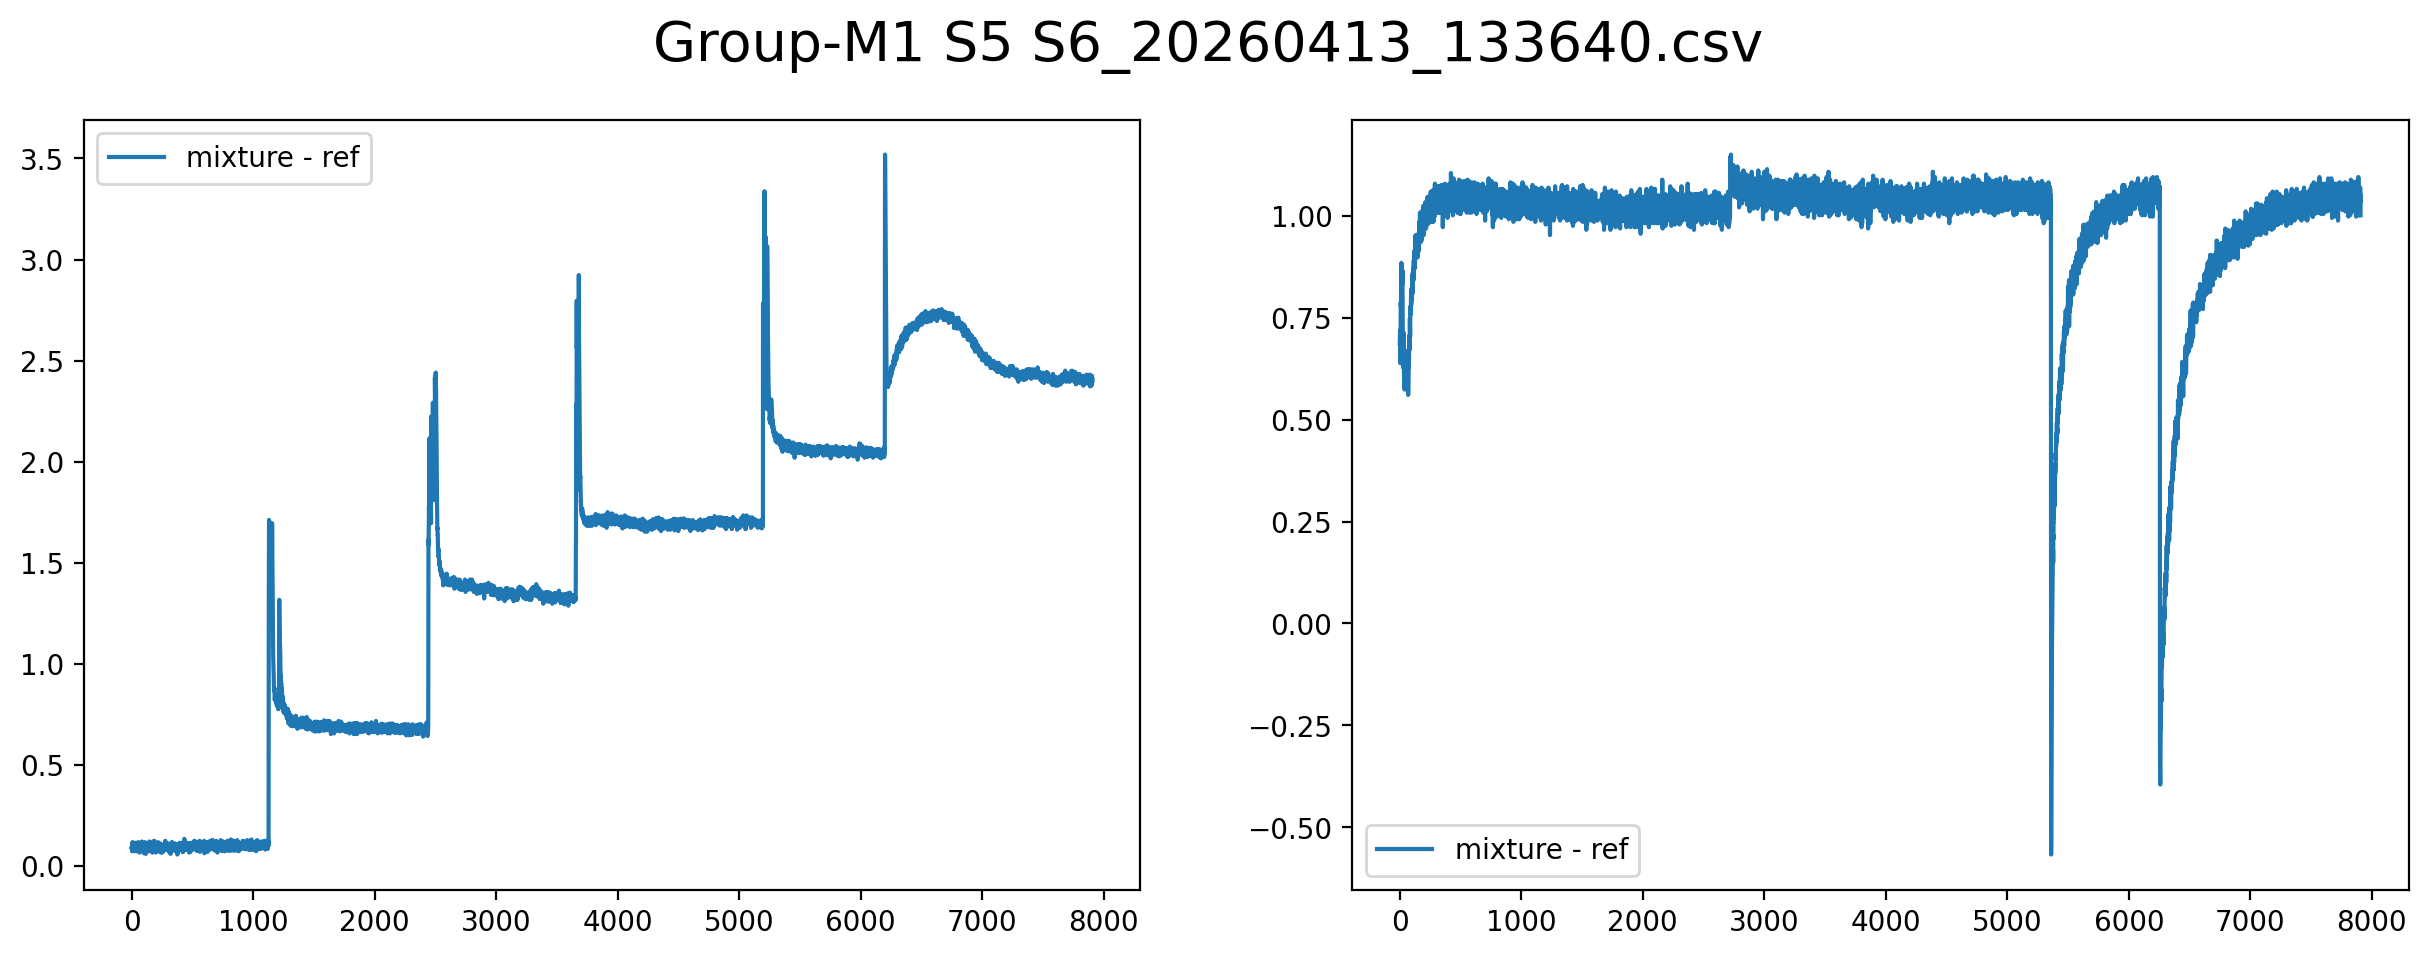

In [3]:
files = glob('G*.csv')

for file in files:
    df = pd.read_csv(file)
    fig,ax = plt.subplots(1,2,dpi=200, figsize=(15,5))
    
    ax[0].plot(df['t'], df[df.columns[-1]] - df[df.columns[-2]], label='mixture - ref')
    ax[0].legend()

    ax[1].plot(df['t'], df[df.columns[-3]] - df[df.columns[-4]], label='mixture - ref')
    ax[1].legend()
    fig.suptitle(file, fontsize=20)

130236
13:02
111601
11:16
133640
13:36


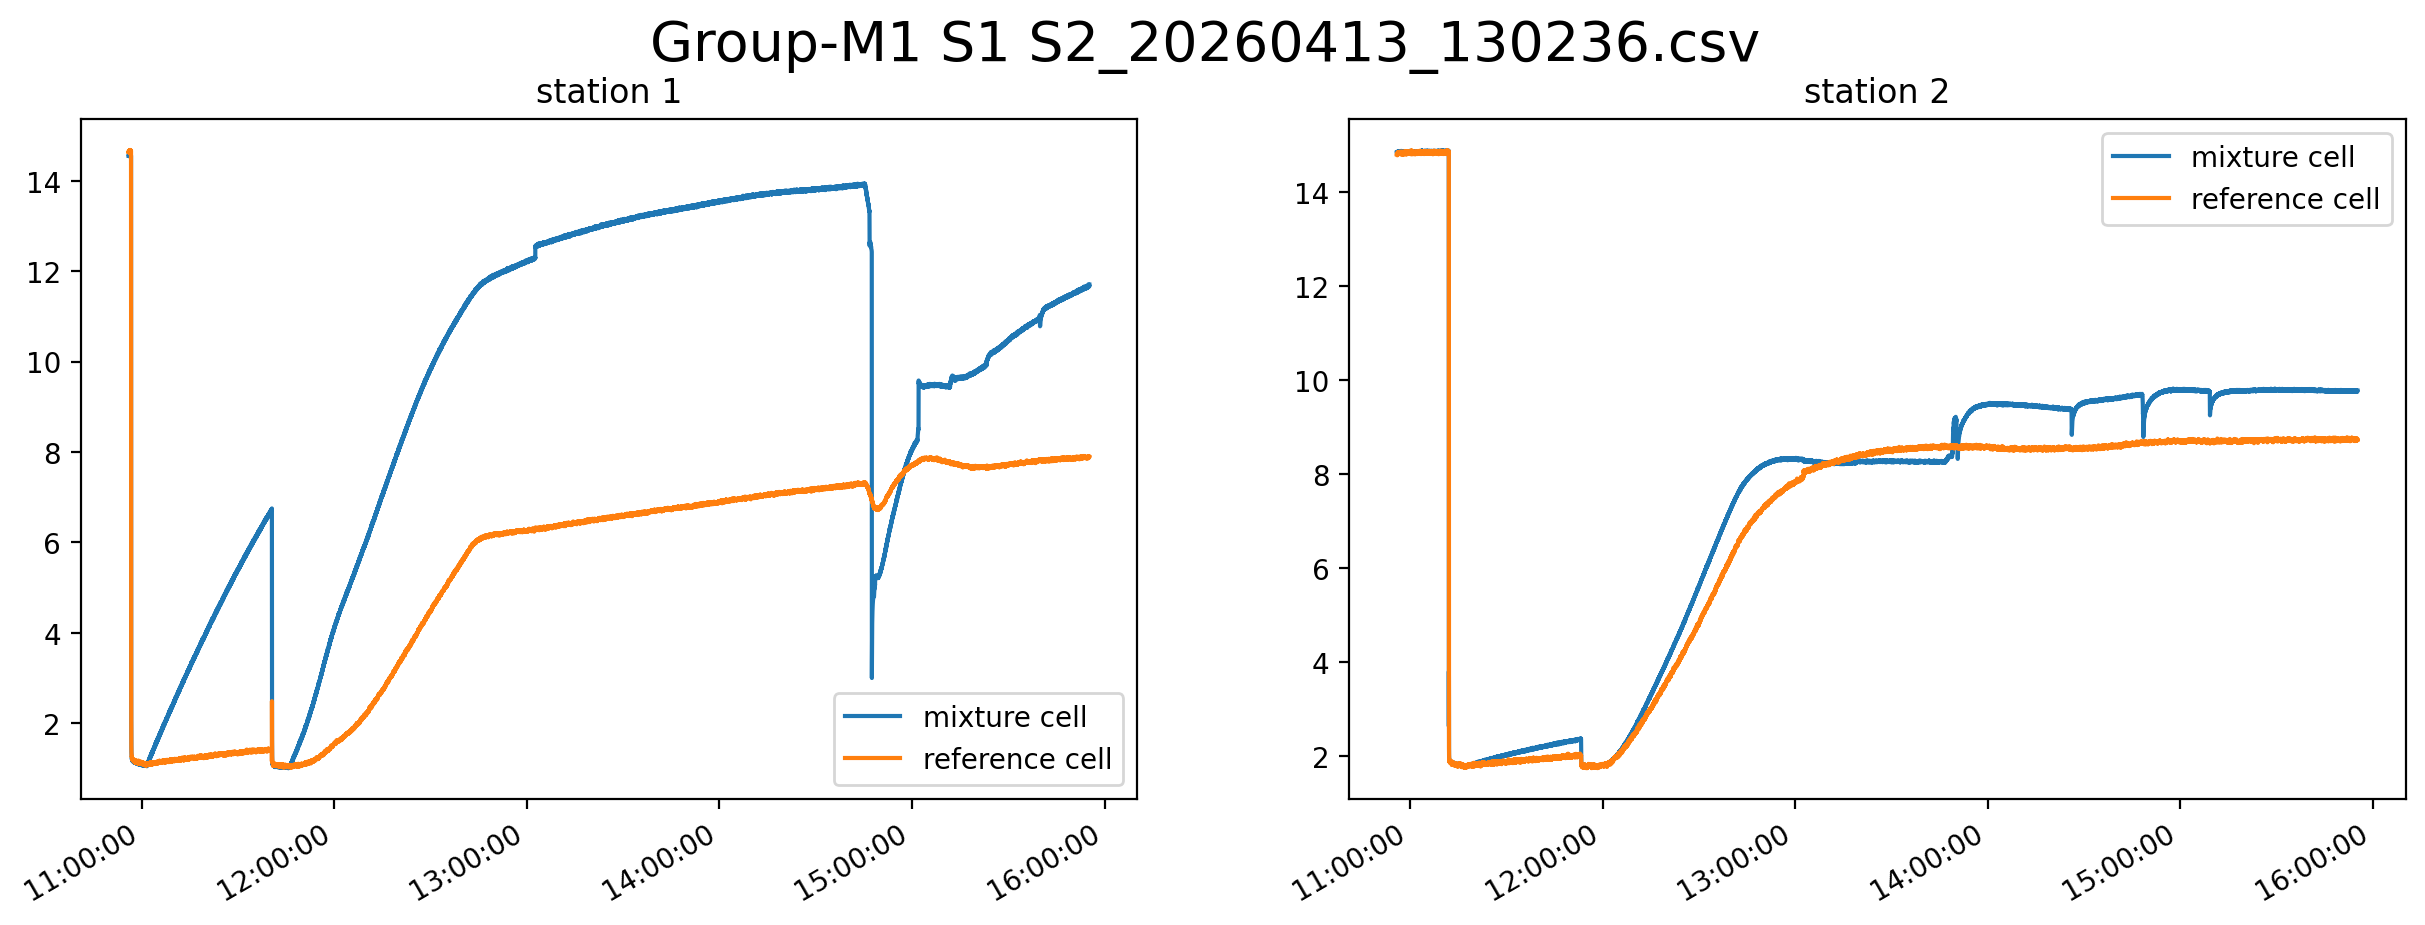

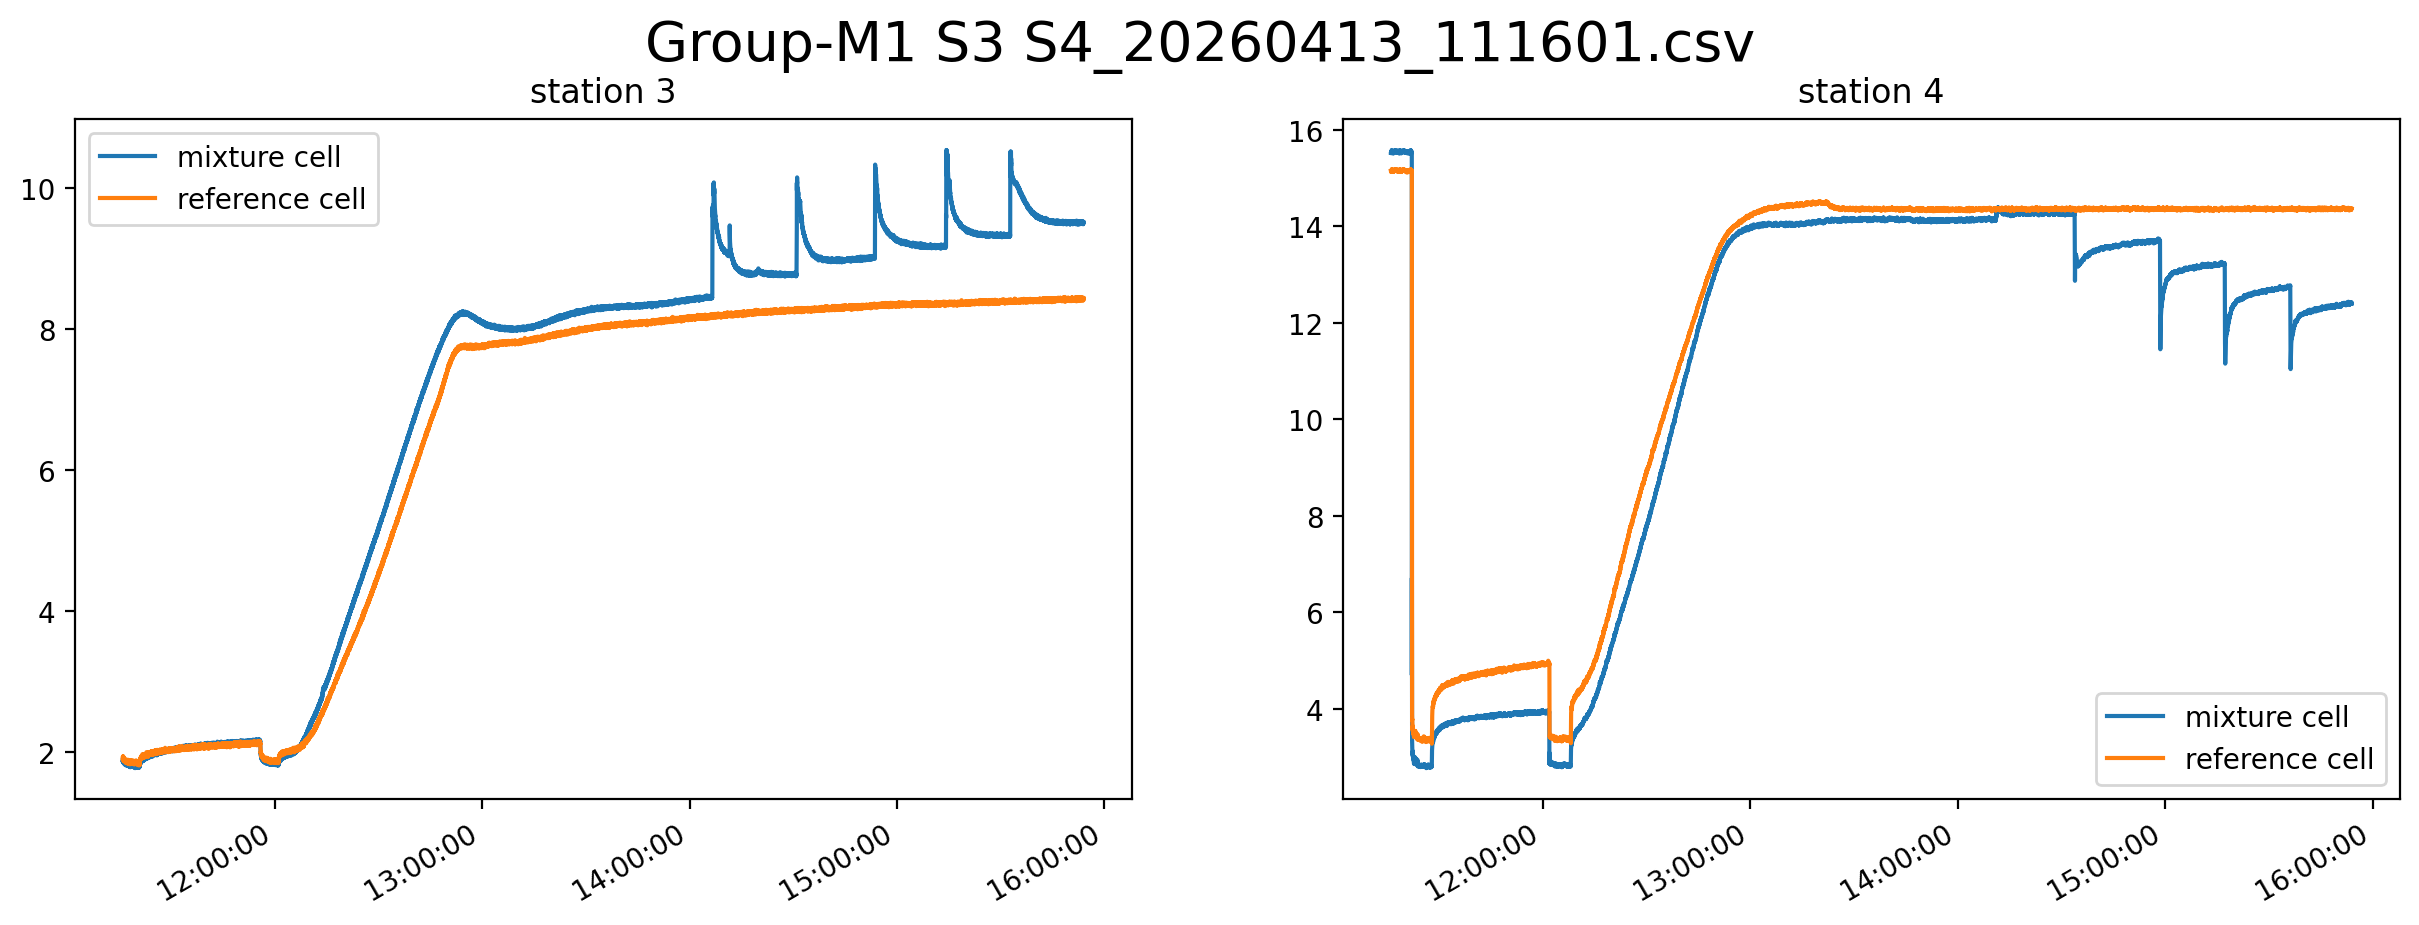

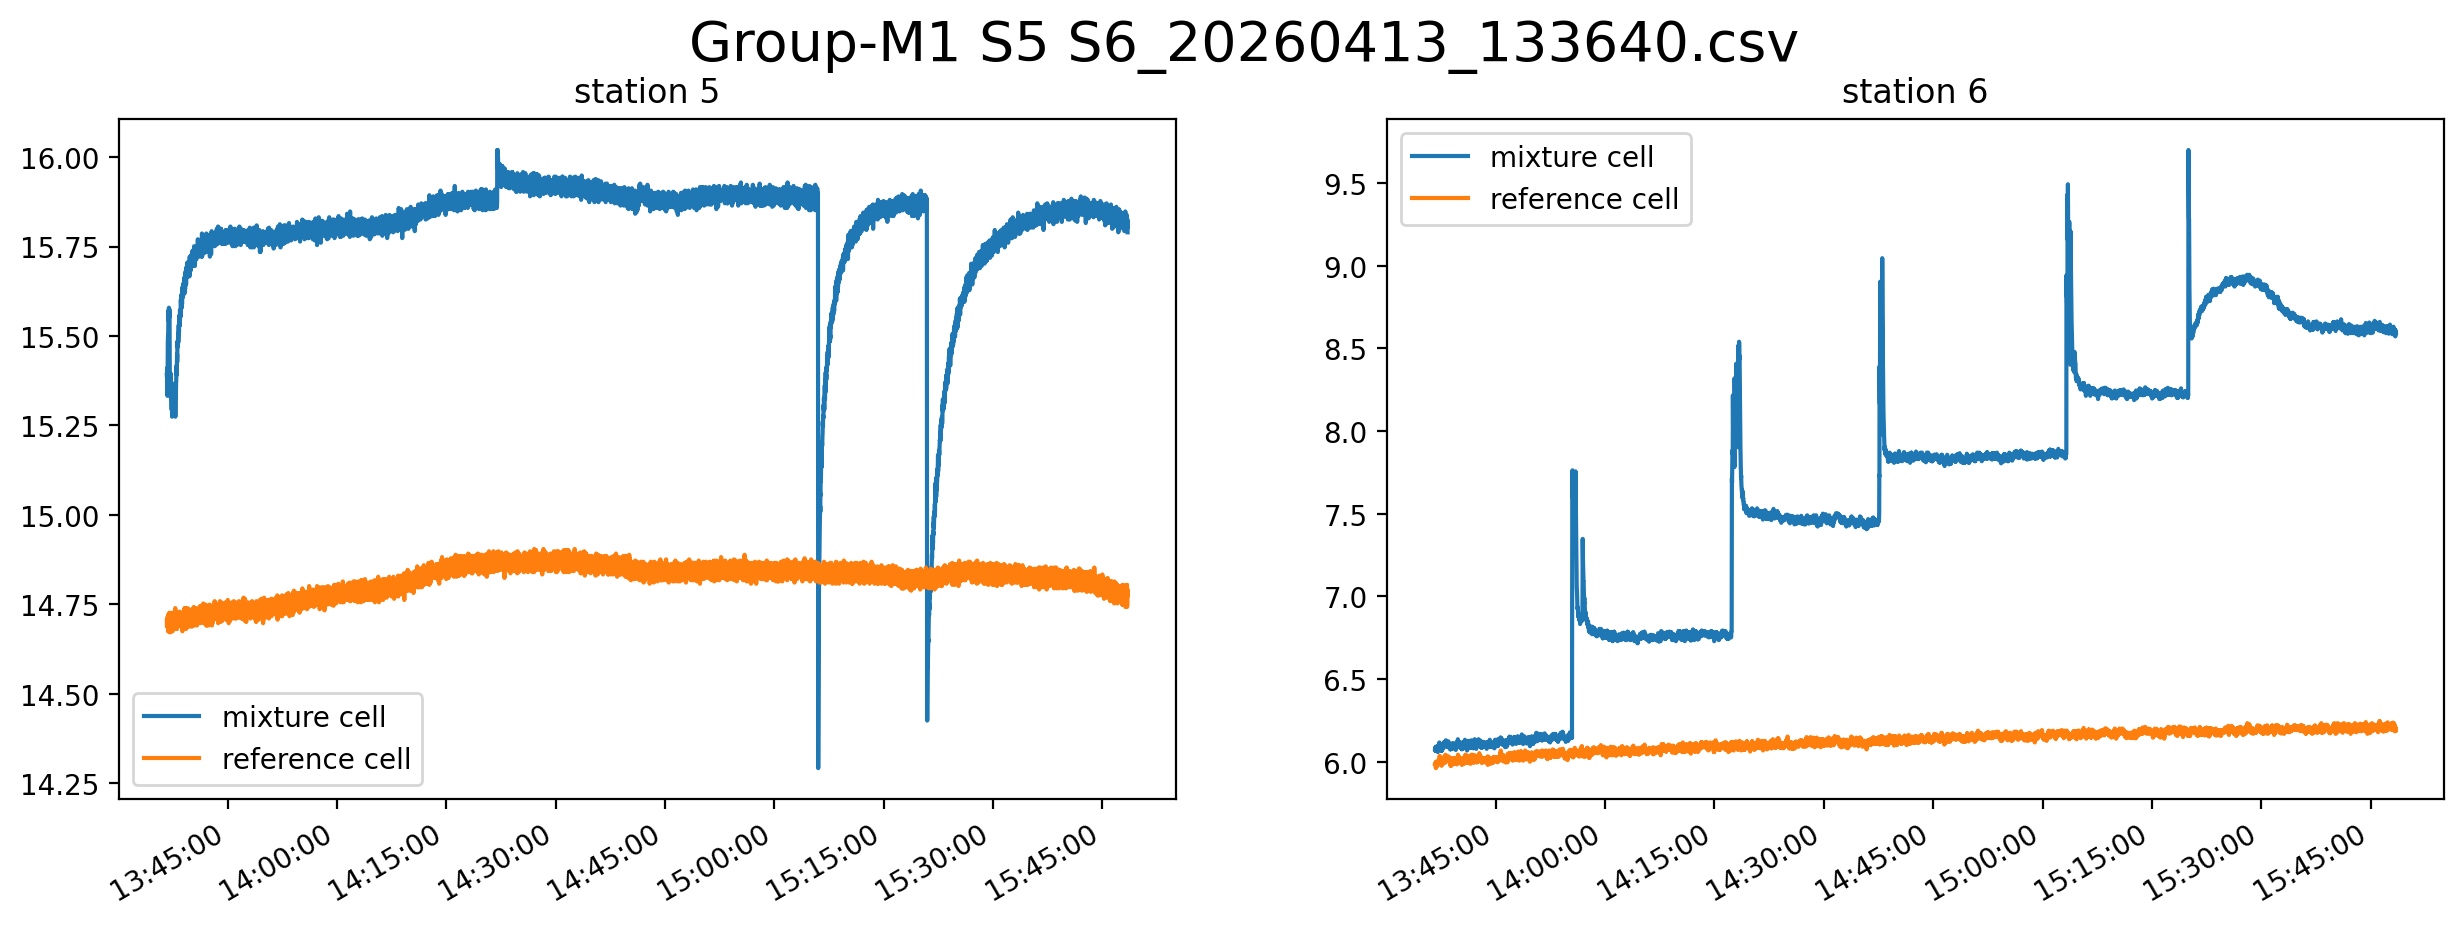

In [4]:
import numpy as np

window_size = 1
kernel = np.ones(window_size) / window_size
stations = [['station 1','station 2'], 
            ['station 3','station 4'], 
            ['station 5','station 6']]

for file,station in zip(files, stations):
    start_time = file.split('_')[-1].split('.')[0]
    print(start_time)
    try:
        human_time = pd.to_datetime(start_time, format="%H%M%S").strftime("%H:%M")
    except ValueError:
        human_time = 0

    print(human_time)

    df = pd.read_csv(file)
    fig, ax = plt.subplots(1, 2, dpi=200, figsize=(15, 5))

    d1 = df[df.columns[-3]] 
    d2 = df[df.columns[-1]] 
    d1_ref = df[df.columns[-4]]
    d2_ref = df[df.columns[-2]]

    # temperatures
    T1 = df[df.columns[-9]] 
    T2 = df[df.columns[-5]] 
    T1ref = df[df.columns[-12]] 
    T2ref = df[df.columns[-8]] 

    d1_ma = np.convolve(d1, kernel, mode='same')
    d2_ma = np.convolve(d2, kernel, mode='same')

    if human_time != 0:
        base_time = pd.to_datetime(start_time, format="%H%M%S")
        t_human = base_time + pd.to_timedelta(df['t'], unit='s')
    else:
        # fallback to a pandas-parseable datetime axis
        t_human = pd.to_datetime(df['t'], unit='s', origin='unix')

    # save per-station CSVs: time, mixture cell, reference cell
    out1 = pd.DataFrame({
        "time": t_human.dt.strftime("%Y-%m-%d %H:%M:%S.%f"),
        "mixture cell P": d1_ma,
        "reference cell P": d1_ref,
        "mixture cell T": T1,
        "reference cell T": T1ref
    })
    out1.to_csv(f"{station[0].replace(' ', '_')}.csv", index=False)

    out2 = pd.DataFrame({
        "time": t_human.dt.strftime("%Y-%m-%d %H:%M:%S.%f"),
        "mixture cell P": d2_ma,
        "reference cell P": d2_ref,
        "mixture cell T": T1,
        "reference cell T": T1ref
    })
    out2.to_csv(f"{station[1].replace(' ', '_')}.csv", index=False)

    if human_time != 0:
        ax[0].plot(t_human, d1_ma, label='mixture cell')
        ax[0].plot(t_human, d1_ref, label='reference cell')
        ax[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%H:%M:%S"))
        fig.autofmt_xdate(rotation=30)
    else:
        ax[0].plot(df['t'], d1_ma, label='mixture cell')
        ax[0].plot(df['t'], d1_ref, label='reference cell')
    ax[0].set(title=station[0])
    ax[0].legend()

    if human_time != 0:
        ax[1].plot(t_human, d2_ma, label='mixture cell')
        ax[1].plot(t_human, d2_ref, label='reference cell')
        ax[1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%H:%M:%S"))
        fig.autofmt_xdate(rotation=30)
    else:
        ax[0].plot(df['t'], d2_ma, label='mixture - ref (MA5)')
    ax[1].set(title=station[1])
    ax[1].legend()

    fig.suptitle(file, fontsize=20)